In [1]:
%matplotlib inline 
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image




# 1 -  Exploration

In [2]:
df = pd.read_csv("data/digits-raw.csv", header=None)
np.random.seed(0)

max_label = df[1].max()
# print(max_label)
random_imgs = []

#print(df[df[1] == 10])

for i in range(max_label+1):
    df_i = df[df[1] == i]
    if df_i.empty is True:
        continue
    img = df_i.sample()
    # Drop the first two columns (id and label)
    img = img.iloc[:,2:]
    # Reshape as 28x28
    img = np.reshape(img, (28,28))
    # Show inline
    x = Image.fromarray(np.uint8(img), 'L')
    display(x)

# img = df.iloc[100][2:]
# img = np.reshape(img, (28,28))

# img



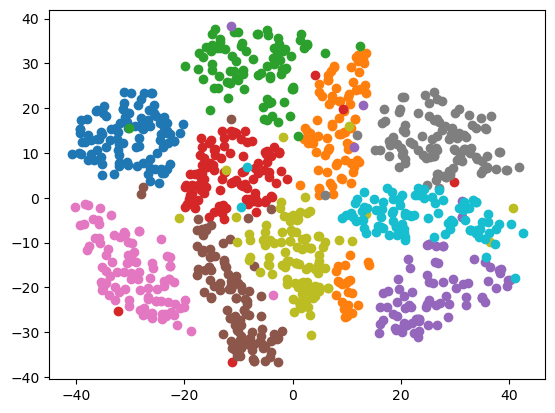

In [3]:
samples = np.random.randint(0, df.shape[0], size=1000)
df_emb = pd.read_csv("data/digits-embedding.csv", header=None)
dots = []

max_label = df_emb[1].max()
# print(max_label)
labeled_dots = {}
for i in range(max_label+1):
    labeled_dots[i] = {'x' : [], 'y': []}

dot = df_emb.iloc[500]
for i in samples:
    dot = df_emb.iloc[i]
    labeled_dots[dot[1]]['x'].append(dot[2])
    labeled_dots[dot[1]]['y'].append(dot[3])

for i in range(max_label+1):
    plt.plot(labeled_dots[i]["x"], labeled_dots[i]["y"], 'o')
plt.show()


In [4]:
def dist(x, y):
    return np.sqrt((x[0] - y[0]) ** 2 + (x[1] - y[1]) ** 2)

In [5]:
def nearest_cluster(p, centroids):
    nc = -1
    nc_dist = np.finfo(np.float64).max
    for c in centroids:
        d = dist(p, c)
        # print(f'd{ci}: {d} ', end='')
        if d < nc_dist:
            nc = c
            nc_dist = d
    return nc

In [6]:

def make_clusters(df, clusters):
    centroids = clusters.keys()
    # cluster data with nearest centroid
    for i, row in df.iterrows():
        # print(f'point: {i} ', end='')
        p = (float(row[2]), float(row[3]))
        p = np.array(row[2:])

        # nc = -1
        # nc_dist = np.finfo(np.float64).max
        # # find the nearest centroid
        # for c in centroids:
        #     d = dist(p, c)
        #     # print(f'd{ci}: {d} ', end='')
        #     if d < nc_dist:
        #         nc = c
        #         nc_dist = d
        nc = nearest_cluster(p, centroids)
            
        # add to the cluster found
        clusters[nc].append(i) 
        # print(f"closest: {cc_dist}")
        # print(row[2], row[3])

    return clusters


In [7]:
# recompute centroids
def recompute_centroids(clusters):
    new_cluster = {}
    for c in clusters:
        # print(f"size of new cluster: {len(clusters[c])}")
        mask = df[0].isin(clusters[c])
        points = df[mask]
        p_x, p_y = points[2], points[3]
        mean = np.mean(p_x), np.mean(p_y)
        # Wipe out new cluster
        new_cluster[mean] = []
        # print(f"size of new cluster: {len(l)}")
    return(new_cluster)

In [8]:
def clusters_equal(cluster1, cluster2):
    k1s, k2s = cluster1.keys(), cluster2.keys()
    if(len(k1s) != len(k2s)):
        return False
    for k1, k2 in zip(k1s, k2s):
        if(k1 != k2):
            return False

    for k1, k2 in zip(k1s, k2s):
        if cluster1[k1] != cluster2[k2]:
            return False

    return True


def cluster_size(clusters):
    s = 0
    for i, c in enumerate(clusters.keys()):
        l = len(clusters[c])
        s += l
    return s

In [9]:
# def kmeans(df, k=10, max_it=50):
k = 10
max_it = 50
df = df_emb#.sample(100)

centroids = np.random.randint(0, df.shape[0], size=k)
# print(centroids)

pre_clusters = {}
for c in centroids:
    centroid_p = df.iloc[c][2], df.iloc[c][3]
    pre_clusters[centroid_p] = []
    # print(df.iloc[c][2:])

clusters = {}
old_clusters = {}

for i in range(max_it):
    print(f'epoch:{i}')
    clusters = make_clusters(df, pre_clusters)
    pre_clusters = recompute_centroids(clusters)
    if(clusters_equal(clusters, old_clusters)):
        break
    old_clusters = clusters



epoch:0
epoch:1
epoch:2
epoch:3
epoch:4
epoch:5
epoch:6
epoch:7
epoch:8
epoch:9
epoch:10
epoch:11
epoch:12
epoch:13
epoch:14
epoch:15
epoch:16
epoch:17
epoch:18
epoch:19
epoch:20
epoch:21
epoch:22
epoch:23
epoch:24
epoch:25
epoch:26
epoch:27
epoch:28
epoch:29
epoch:30
epoch:31
epoch:32
epoch:33
epoch:34
epoch:35
epoch:36
epoch:37
epoch:38
epoch:39
epoch:40
epoch:41
epoch:42
epoch:43
epoch:44
epoch:45
epoch:46
epoch:47
epoch:48
epoch:49


In [10]:
# check if clustering was correct
ks = 0
s = 0
for i, c in enumerate(clusters.keys()):
    l = len(clusters[c])
    print(f'cluster{i} size: {l}')
    s += l

if(s == len(df)):
    print("all data was properly clustered")
else:
    print(f"mismatch in final size of clusters, s:{s} != {len(df)}")


cluster0 size: 2206
cluster1 size: 1873
cluster2 size: 1878
cluster3 size: 2060
cluster4 size: 2221
cluster5 size: 1628
cluster6 size: 2081
cluster7 size: 1804
cluster8 size: 2060
cluster9 size: 2189
all data was properly clustered


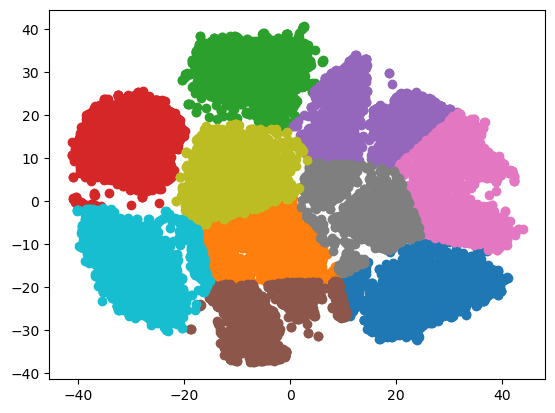

In [31]:

for c in clusters.keys():
    mask = df[0].isin(clusters[c])
    points = df[mask] 
    points = points.iloc[:,2:]

    plt.plot(points[2], points[3], 'o')
plt.show()

In [11]:
c = list(clusters.keys())[2]
mask = df[0].isin(clusters[c])
points = df[mask] 
points = np.array(points.iloc[:,2:])
print(c)
c = np.array(c)
d = np.linalg.norm(points-c)
print(d)


(-7.273816226845581, 29.23151670205005)
347.5315888041901


In [97]:
# Within cluster distance
import scipy.spatial.distance as sp
wcs = []

for c in clusters:
    mask = df[0].isin(clusters[c])
    points = df[mask] 
    points = np.array(points.iloc[:,2:])
    l = sp.pdist(points) 
    wcs.append(np.sum(l))

wcss = np.mean(wcs)
print(f"WCSS: {wcss}")


WCSS: 21975170.538508914


In [98]:
import functools
import scipy.spatial.distance as sp

si = []
dists_mem = {}

def compute_dists(p, points):
    dists = []
    keys = dists_mem.keys()
    pb = p.tobytes()
    for p1 in points:
        d = -1
        p1b = p1.tobytes()
        if((pb, p1b) in keys):
            d = dists_mem[(pb,p1b)]
        elif((p1b,pb)) in keys:
            d = dists_mem[(p1b, pb)]
        else:
            d = np.linalg.norm(p1-p)
            dists_mem[(pb, p1b)] = d
        dists.append(d)
    return dists

for c in clusters:
    mask = df[0].isin(clusters[c])
    points = df[mask] 
    points = np.array(points.iloc[:,2:])
    other_clusters = [k for k in clusters.keys() if k != c]
    dists = sp.squareform(sp.pdist(points))


    nc = nearest_cluster(c, other_clusters)
    mask = df[0].isin(clusters[nc])
    points_nc = df[mask]
    points_nc = np.array(points_nc.iloc[:,2:])


    for i, row in enumerate(dists):
        p = points[i]
        a = np.average(row)#/len(row)
        dists = points_nc - p
        dbs = compute_dists(p, points_nc)#/len(points_nc)
        b = np.average(dbs)
        si.append((b - a) / max(a, b))

sc = np.average(si)
print(f'SC:{sc}')
# 1m


SC:0.4847662704260575


In [133]:
# Calculate NMI
import math

denominator = 0
#print(df)

h_y = 0
for i in range(10):
    df_c = df[df[1] == i]
    p_c = df_c.size/ df.size
    h_y += p_c * math.log(p_c)
# print(lhs)

h_c = 0
for c in clusters:
    mask = df[0].isin(clusters[c])
    p_g = df[mask].size / df.size
    h_c += p_g * math.log(p_g)
    #print(p_g)
    # points_c = np.array(points_c.iloc[:,0])
# print(rhs)
# denominator = - h_y - h_c
# print(denominator)

h_y_c = 0
for c in clusters:
    mask = df[0].isin(clusters[c])
    df_cluster = df[mask]
    p_c = df_cluster.size / df.size
    p_log = 0
    for i in range(10):
        p_y = df_cluster[df_cluster[1] == i]
        if p_y.size != 0:
            p_y_c = p_y.size / df_cluster.size
            p_log += p_y_c * math.log(p_y_c)
    h_y_c += -p_c * p_log
    # print("pc ", p_c)
    # print("p_log ", p_log)
    # print("cond_entr ", -p_c * p_log)
h_y = -h_y
h_c = -h_c
print(f'H(Y) = {h_y}')
print(f'H(C) = {h_c}')
print(f'H(Y|C) = {h_y_c}')
mutual_gain = (2 * (h_y - h_y_c)) / (h_y + h_c)
print("MMI: ", mutual_gain)

H(Y) = 2.300613103863495
H(C) = 2.2981386922432008
H(Y|C) = 0.6428574101192389
MMI:  0.720958976367332
